# 04 — Exploratory Analysis

Visual exploration of the master dataset:
1. Raw WiFi connections vs. deduplicated headcounts
2. Daily and weekly occupancy patterns
3. Calendar effects (day-type)
4. Occupancy ↔ energy correlation

**Input:** `data/processed/dataset_smart_campus_master.csv`


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PROCESSED = Path('../data/processed')
sns.set_theme(style="whitegrid")

df = pd.read_csv(DATA_PROCESSED / 'dataset_smart_campus_master.csv', parse_dates=['Timestamp'])
print(f"Master dataset shape: {df.shape}")
print(f"Date range: {df['Timestamp'].min()} → {df['Timestamp'].max()}")
df.head()


Master dataset shape: (8784, 10)
Date range: 2024-01-01 01:00:00 → 2025-01-01 00:00:00


,Timestamp,Consumo_kWh,Temperatura,Lluvia,Aules_Ocupades,Ocupacio_Percent,tipus_dia,Dia_Semana_Num,Dia_Semana,Ocupacion_Simulada
0,2024-01-01 01:00:00,96,8.0,0.0,0.0,0.0,Vacances,0,Lunes,0.0
1,2024-01-01 02:00:00,96,7.7,0.0,0.0,0.0,Vacances,0,Lunes,0.0
2,2024-01-01 03:00:00,97,7.5,0.0,0.0,0.0,Vacances,0,Lunes,0.0
3,2024-01-01 04:00:00,96,7.7,0.0,0.0,0.0,Vacances,0,Lunes,0.0
4,2024-01-01 05:00:00,95,7.6,0.0,0.0,0.0,Vacances,0,Lunes,0.0


## 1. Inspect a representative week (mid-January)

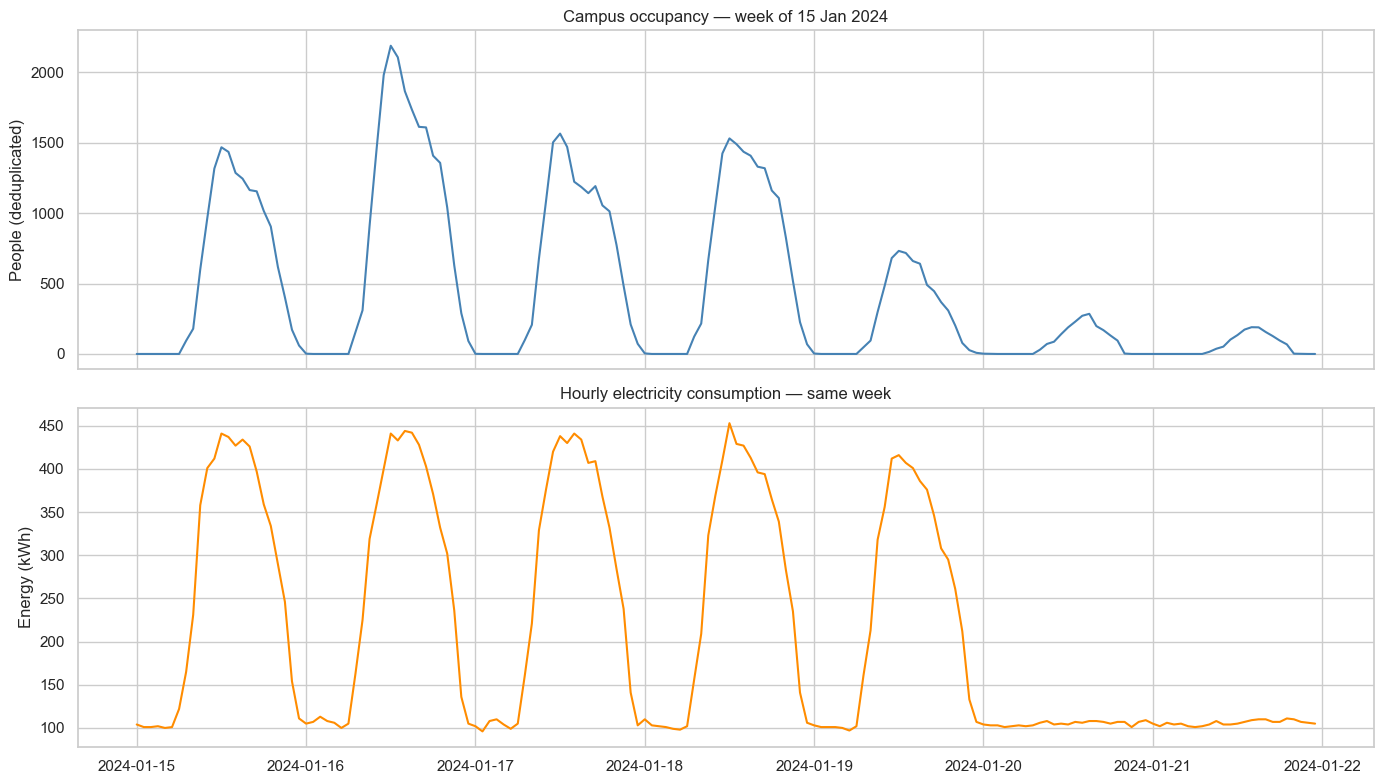

In [7]:
fecha_inicio = pd.to_datetime('2024-01-15')
fecha_fin = pd.to_datetime('2024-01-21 23:59')
df_semana = df[(df['Timestamp'] >= fecha_inicio) & (df['Timestamp'] <= fecha_fin)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_semana['Timestamp'], df_semana['Ocupacion_Simulada'], color='steelblue')
axes[0].set_ylabel("People (deduplicated)")
axes[0].set_title("Campus occupancy — week of 15 Jan 2024")

axes[1].plot(df_semana['Timestamp'], df_semana['Consumo_kWh'], color='darkorange')
axes[1].set_ylabel("Energy (kWh)")
axes[1].set_title("Hourly electricity consumption — same week")

plt.tight_layout()
plt.show()


## 2. Average daily profile by day type

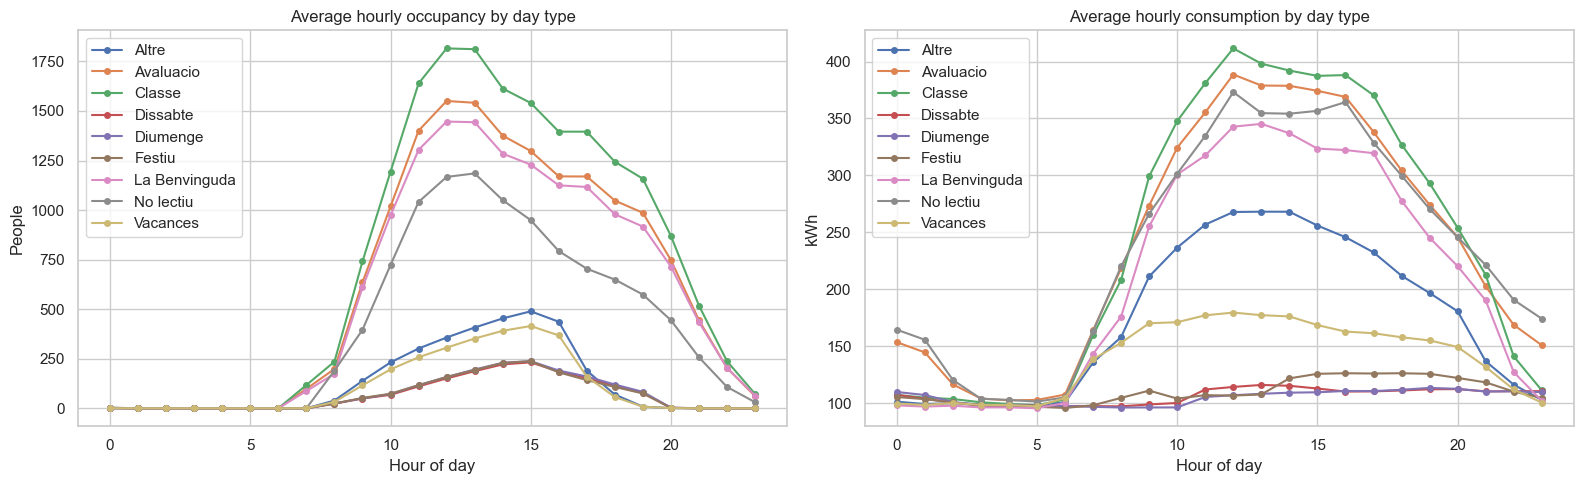

In [8]:
# Aggregate: average occupancy and consumption per (day_type, hour)
df['Hora'] = df['Timestamp'].dt.hour

perfil = df.groupby(['tipus_dia', 'Hora']).agg(
    Ocupacion=('Ocupacion_Simulada', 'mean'),
    Consumo=('Consumo_kWh', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for tipo, datos in perfil.groupby('tipus_dia'):
    axes[0].plot(datos['Hora'], datos['Ocupacion'], label=tipo, marker='o', markersize=4)
    axes[1].plot(datos['Hora'], datos['Consumo'],   label=tipo, marker='o', markersize=4)

axes[0].set_title("Average hourly occupancy by day type")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("People")
axes[0].legend()

axes[1].set_title("Average hourly consumption by day type")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("kWh")
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Occupancy → energy scatter

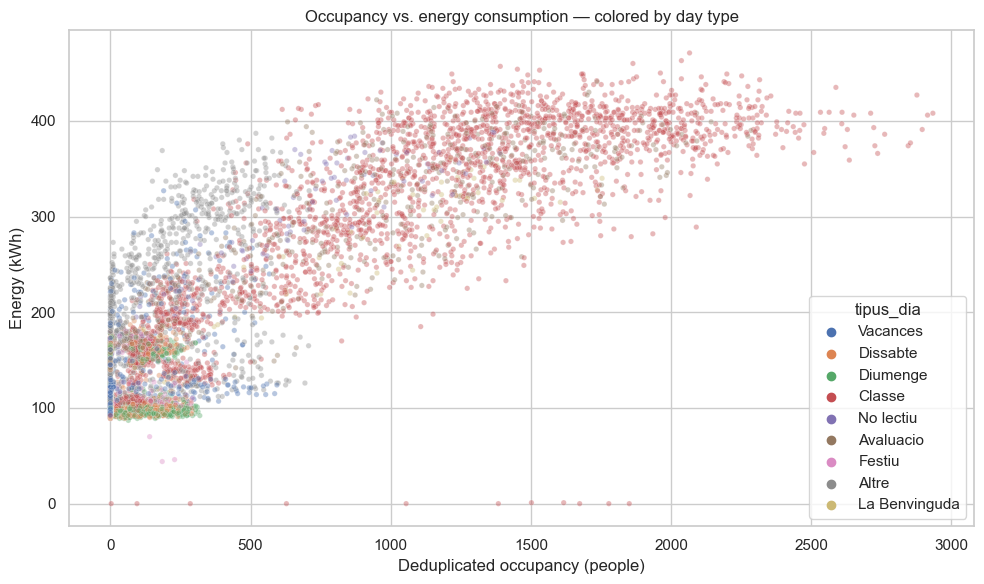


Correlation matrix:
                    Ocupacion_Simulada  Consumo_kWh  Temperatura  Lluvia
Ocupacion_Simulada               1.000        0.881        0.096   0.004
Consumo_kWh                      0.881        1.000        0.091   0.037
Temperatura                      0.096        0.091        1.000  -0.020
Lluvia                           0.004        0.037       -0.020   1.000


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Ocupacion_Simulada', y='Consumo_kWh',
                hue='tipus_dia', alpha=0.4, s=15, ax=ax)
ax.set_title("Occupancy vs. energy consumption — colored by day type")
ax.set_xlabel("Deduplicated occupancy (people)")
ax.set_ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()

# Correlation
corr = df[['Ocupacion_Simulada', 'Consumo_kWh', 'Temperatura', 'Lluvia']].corr()
print("\nCorrelation matrix:")
print(corr.round(3))


## 4. Weekly heatmap

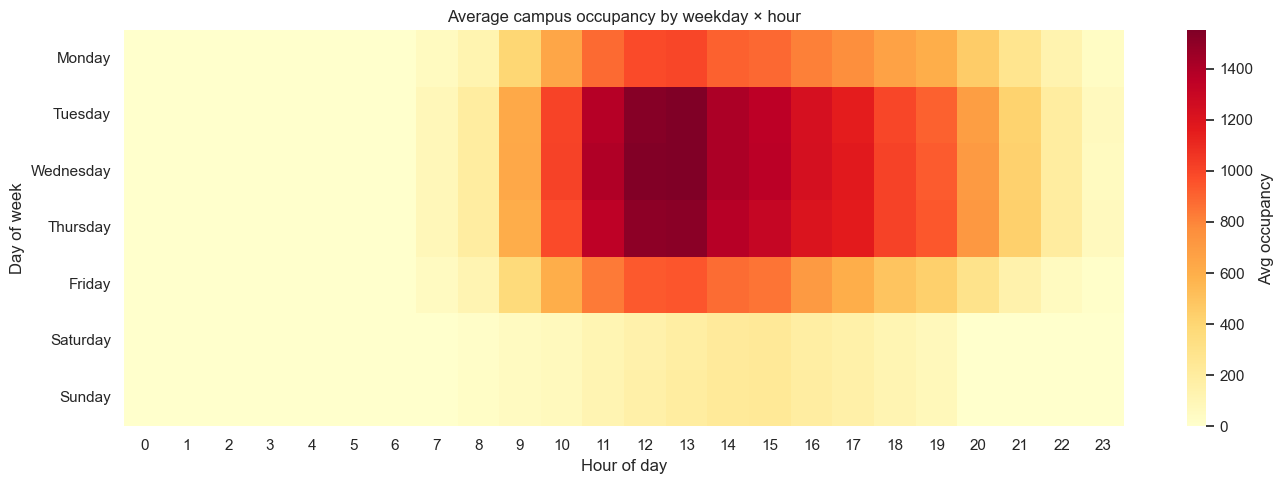

In [10]:
df['Hora'] = df['Timestamp'].dt.hour
df['Dia_Sem'] = df['Timestamp'].dt.day_name()

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (
    df.groupby(['Dia_Sem', 'Hora'])['Ocupacion_Simulada']
    .mean()
    .unstack()
    .reindex(orden_dias)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Avg occupancy'}, ax=ax)
ax.set_title("Average campus occupancy by weekday × hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
plt.tight_layout()
plt.show()
